**EDA and data preperation for the models**

# Imports

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#from google.colab import files
import gc

# Helper Functions

## Functions for missing values

In [6]:
missing_9_vars = ['MAGER14', 'FAGECOMB', 'GESTREC10', 'GESTREC3', 'BWTR14',
                  'APGAR5', 'APGAR10', 'PWgt_R', 'DWgt_R', 'WTGAIN', 'MHTR']

missing_88_vars = ['RF_PDIAB', 'RF_GDIAB', 'RF_PHYPE', 'RF_GHYPE', 'RF_EHYPE',
                   'RF_PPB', 'RF_INFT', 'RF_DRG', 'RF_ART', 'RF_CESAR', 'RF_CESARN',
                   'PRECARE', 'PREVIS', 'CIG_0_R', 'CIG_1_R', 'CIG_2_R', 'CIG_3_R',
                   'IP_GON', 'IP_SYPH', 'IP_CHLAM', 'IP_HEPB', 'IP_HEPC', 'LD_INDL',
                   'LD_AUGM', 'LD_CHOR', 'LD_STER', 'LD_ANTB', 'LD_ANES', 'AB_NICU',
                   'AB_SURF', 'AB_ANTI', 'AB_SEIZ', 'MM_MTR', 'MM_PLAC', 'MM_RUPT',
                   'MM_UHYST']


In [ ]:
nchs_missing_per_var = {
    "MAGER14": ["99", "99.9", "", " "],
    "MRACE31": ["99", "99.9", "", " "],
    "MEDUC": ["99", "99.9", "", " "],
    "DMAR": ["99", "99.9", "", " "],
    "MBSTATE_REC": ["99", "99.9", "", " "],
    "RESTATUS": ["99", "99.9", "", " "],
    "WIC": ["99", "99.9", "", " "],
    "PAY": ["99", "99.9", "", " "],

    "FAGECOMB": ["99", "99.9", "99.0", "", " "],
    "FRACE31": ["99", "99.9", "", " "],
    "FEDUC": ["99", "99.9", "", " "],

    "RF_PDIAB": ["U", "99", "99.9", "", " "],
    "RF_GDIAB": ["U", "99", "99.9", "", " "],
    "RF_PHYPE": ["U", "99", "99.9", "", " "],
    "RF_GHYPE": ["U", "99", "99.9", "", " "],
    "RF_EHYPE": ["U", "99", "99.9", "", " "],
    "RF_PPB": ["U", "99", "99.9", "", " "],
    "RF_INFT": ["U", "99", "99.9", "", " "],
    "RF_DRG": ["U", "99", "99.9", "", " "],
    "RF_ART": ["U", "99", "99.9", "", " "],
    "RF_CESAR": ["U", "99", "99.9", "", " "],
    "RF_CESARN": ["U", "99", "99.9", "", " "],
    "NO_RISKS": ["U", "99", "99.9", "", " "],

    "PRECARE": ["99", "99.9", "", " "],
    "PREVIS": ["99", "99.9", "", " "],

    "CIG_0_R": ["99", "99.9", "", " "],
    "CIG_1_R": ["99", "99.9", "", " "],
    "CIG_2_R": ["99", "99.9", "", " "],
    "CIG_3_R": ["99", "99.9", "", " "],

    "MHTR": ["99", "99.9", "", " "],
    "BMI": ["99", "99.9", "", " "],
    "BMI_R": ["9", "99", "99.9", "", " "],
    "PWgt_R": ["999", "", " "],
    "DWgt_R": ["999", "", " "],
    "WTGAIN": ["999", "99", "", " "],

    "LBO_REC": ["99", "99.9", "", " "],
    "TBO_REC": ["99", "99.9", "", " "],
    "PRIORLIVE": ["99", "99.9", "", " "],
    "PRIORDEAD": ["99", "99.9", "", " "],
    "PRIORTERM": ["99", "99.9", "", " "],

    "ILLB_R11": ["U", "99", "99.9", "", " "],
    "ILOP_R11": ["U", "99", "99.9", "", " "],
    "ILP_R11": ["U", "99", "99.9", "", " "],
    "IP_GON": ["U", "99", "99.9", "", " "],
    "IP_SYPH": ["U", "99", "99.9", "", " "],
    "IP_CHLAM": ["U", "99", "99.9", "", " "],
    "IP_HEPB": ["U", "99", "99.9", "", " "],
    "IP_HEPC": ["U", "99", "99.9", "", " "],
    "NO_INFEC": ["U", "99", "99.9", "", " "],

    "LD_INDL": ["U", "99", "99.9", "", " "],
    "LD_AUGM": ["U", "99", "99.9", "", " "],
    "LD_CHOR": ["U", "99", "99.9", "", " "],
    "LD_STER": ["U", "99", "99.9", "", " "],
    "LD_ANTB": ["U", "99", "99.9", "", " "],
    "LD_ANES": ["U", "99", "99.9", "", " "],

    "ME_PRES": ["U", "99", "99.9", "", " "],
    "ME_ROUT": ["U", "99", "99.9", "", " "],
    "ME_TRIAL": ["U", "99", "99.9", "", " "],

    "DMETH_REC": ["99", "99.9", "", " "],
    "RDMETH_REC": ["99", "99.9", "", " "],

    "SEX": ["9", "", " "],
    "COMBGEST": ["99", "99.9", "", " "],
    "GESTREC10": ["99", "99.9", "", " "],
    "GESTREC3": ["99", "99.9", "", " "],
    "BWTR14": ["14", "99", "99.9", "", " "],

    "APGAR5": ["99", "99.9", "", " "],
    "APGAR10": ["99", "99.9", "", " "],

    "AB_AVEN1": ["U", "99", "99.9", "", " "],
    "AB_AVEN6": ["U", "99", "99.9", "", " "],
    "AB_NICU": ["U", "99", "99.9", "", " "],
    "AB_SURF": ["U", "99", "99.9", "", " "],
    "AB_ANTI": ["U", "99", "99.9", "", " "],
    "AB_SEIZ": ["U", "99", "99.9", "", " "],
    "NO_ABNORM": ["U", "99", "99.9", "", " "],

    "CA_ANEN": ["U", "99", "99.9", "", " "],
    "CA_MNSB": ["U", "99", "99.9", "", " "],
    "CA_CCHD": ["U", "99", "99.9", "", " "],
    "CA_CDH": ["U", "99", "99.9", "", " "],
    "CA_OMPH": ["U", "99", "99.9", "", " "],
    "CA_GAST": ["U", "99", "99.9", "", " "],
    "CA_LIMB": ["U", "99", "99.9", "", " "],
    "CA_CLEFT": ["U", "99", "99.9", "", " "],
    "CA_CLPAL": ["U", "99", "99.9", "", " "],
    "CA_DOWN": ["U", "99", "99.9", "", " "],
    "CA_DISOR": ["U", "99", "99.9", "", " "],
    "CA_HYPO": ["U", "99", "99.9", "", " "],
    "NO_CONGEN": ["U", "99", "99.9", "", " "],

    "MM_MTR": ["U", "99", "99.9", "", " "],
    "MM_PLAC": ["U", "99", "99.9", "", " "],
    "MM_RUPT": ["U", "99", "99.9", "", " "],
    "MM_UHYST": ["U", "99", "99.9", "", " "],
    "MM_AICU": ["U", "99", "99.9", "", " "],
    "NO_MMORB": ["U", "99", "99.9", "", " "],

    "T": ["U", "99", "99.9", "", " "],
    "Y": ["U", "99", "99.9", "", " "]
}


# NOTE:
# Values ​​such as 88 (Not applicable / Not collected) are not included as missing,
# because in many variables they represent true irrelevance (e.g. APGAR10 not measured when the newborn is in good condition) and not a technical missing

In [ ]:
import numpy as np

def convert_missing_to_nan(df, missing_dict = nchs_missing_per_var):
    df_clean = df.copy()

    for col, missing_values in missing_dict.items():
        if col not in df_clean.columns:
            continue

        #Keep original data type
        original_dtype = df_clean[col].dtype

        # Convert to string to ensure all missing value representations are treated uniformly
        df_clean[col] = df_clean[col].astype(str)

        # Convert specified missing value representations to NaN
        df_clean[col] = df_clean[col].replace(missing_values, np.nan)

        # Convert back to numeric if the original data type was numeric
        if pd.api.types.is_numeric_dtype(original_dtype):
            df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    return df_clean

# Function to count missing values in a specific column after converting specified missing value representations to NaN
def count_missing_column(df, col, missing_dict = nchs_missing_per_var):
  df_clean = convert_missing_to_nan(df, missing_dict)
  return df_clean[col].isna().sum()

In [ ]:
# Filling missing values based on the distribution of existing values in the column
def fill_by_prob(df, col):
  probs = df[col].value_counts(normalize=True)
  return df[col].apply(lambda x: np.random.choice(probs.index, p=probs.values) if pd.isna(x) else x)

# Filling summary variables
def fill_summary_col(df, start, summary_col):
  lst = [col for col in df.columns if col.startswith(start)]
  for idx, row in df.iterrows():
    df.at[idx, summary_col] = 1 if (row[lst] == 1).any() else 0


## Others

In [10]:
column_hebrew_meaning = {
    "MAGER14": "גיל האם בלידה",
    "MRACE31": "גזע האם",
    "MEDUC": "השכלה של האם",
    "DMAR": "מצב משפחתי של האם",
    "MBSTATE_REC": "מדינת מגורי האם",
    "RESTATUS": "סטטוס הרשמה",
    "WIC": "זכאות לתוכנית CIW",
    "PAY": "תשלום או ביטוח",
    "FAGECOMB": "גיל האב",
    "FRACE31": "גזע האב",
    "FEDUC": "השכלה של האב",
    "RF_PDIAB": "סוכרת לפני הריון",
    "RF_GDIAB": "סוכרת בהריון",
    "RF_PHYPE": "יתר לחץ דם כרוני",
    "RF_GHYPE": "יתר לחץ דם בהריון",
    "RF_EHYPE": "רעלת הריון",
    "RF_PPB": "דימום לאחר לידה",
    "RF_INFT": "בעיות פוריות",
    "RF_DRG": "שימוש בסמים",
    "RF_ART": "טיפולי פוריות",
    "RF_CESAR": "ניתוח קיסרי קודם",
    "RF_CESARN": "מספר ניתוחי קיסרי קודם",
    "NO_RISKS": "ללא גורמי סיכון",
    "PRECARE": "מעקב הריון",
    "PREVIS": "מספר ביקורי מעקב",
    "CIG_0_R": "עישון ביום כניסה להיריון",
    "CIG_1_R": "עישון - טרימסטר ראשון",
    "CIG_2_R": "עישון - טרימסטר שני",
    "CIG_3_R": "עישון - טרימסטר שלישי",
    "MHTR": "גובה האם באינצ’ים",
    "BMI": "IMB",
    "BMI_R": "IMB לאחר התאמה",
    "PWgt_R": "משקל לפני הריון",
    "DWgt_R": "משקל לידה",
    "WTGAIN": "עלייה במשקל בהריון",
    "LBO_REC": "לידה מוקדמת",
    "TBO_REC": "לידה מונעת",
    "PRIORLIVE": "לידות קודמות חיוביות",
    "PRIORDEAD": "לידות קודמות מתות",
    "PRIORTERM": "לידות קודמות טרמיות",
    "ILLB_R11": "מרווח זמן מאז הלידה הקודמת",
    "ILOP_R11": "מרווח זמן מאז הריון קודם אחר",
    "ILP_R11": "מרווח זמן מאז ההריון הקודם",
    "IP_GON": "זיהום בגונוריאה",
    "IP_SYPH": "זיהום בעגבת",
    "IP_CHLAM": "זיהום בכלמידיה",
    "IP_HEPB": "זיהום הפטיטיס B",
    "IP_HEPC": "זיהום הפטיטיס C",
    "NO_INFEC": "ללא זיהומים",
    "LD_INDL": "אינדוקציה בלידה",
    "LD_AUGM": "האצת לידה",
    "LD_CHOR": "קרע קרומי שליה",
    "LD_STER": "מתן סטרואידים",
    "LD_ANTB": "מתן אנטיביוטיקה",
    "LD_ANES": "הרדמה בלידה",
    "ME_PRES": "מצג העובר",
    "ME_ROUT": "לידה רגילה",
    "ME_TRIAL": "נסיון לידה טבעית לפני קיסרי",
    "DMETH_REC": "שיטת לידה",
    "RDMETH_REC": "שיטת לידה מחודשת",
    "SEX": "מגדר היילוד",
    "COMBGEST": "גיל היריון בשבועות",
    "GESTREC10": "גיל היריון ב-01 קטגוריות",
    "GESTREC3": "גיל היריון ב-3 קטגוריות",
    "BWTR14": "משקל לידה בגרם",
    "APGAR5": "ציון אפגר 5 דקות",
    "APGAR10": "ציון אפגר 01 דקות",
    "DPLURAL": "לידה מרובת עוברים",
    "SETORDER_R": "סדר לידה בהריון",
    "AB_AVEN1": "נשימת תינוק – צורך בהנשמה מיד לאחר הלידה",
    "AB_AVEN6": "נשימת תינוק – צורך בהנשמה מעל 6 שעות",
    "AB_NICU": "אשפוז בפגייה",
    "AB_SURF": "מצוקה נשימתית",
    "AB_ANTI": "טיפול אנטיביוטי",
    "AB_SEIZ": "פרכוסים",
    "NO_ABNORM": "ללא סיבוכים בלידה",
    "CA_ANEN": "אננצפליה",
    "CA_MNSB": "ספינה ביפידה",
    "CA_CCHD": "מום לב חמור",
    "CA_CDH": "מום במערכת העיכול",
    "CA_OMPH": "בקע טבורי",
    "CA_GAST": "מום במערכת העיכול",
    "CA_LIMB": "מום בגפיים",
    "CA_CLEFT": "שפה שסועה",
    "CA_CLPAL": "חך שסוע",
    "CA_DOWN": "תסמונת דאון",
    "CA_DISOR": "הפרעה כרומוזומלית",
    "CA_HYPO": "היפוספדיאס",
    "NO_CONGEN": "ללא מומים מולדים",
    "MM_MTR": "סיבוך מטרלי",
    "MM_PLAC": "סיבוך שליה",
    "MM_RUPT": "קרע שליה",
    "MM_UHYST": "קרע רחם",
    "MM_AICU": "טיפול נמרץ אימהי",
    "NO_MMORB": "ללא סיבוכים אימהיים",
    "T": "עישנה או לא",
    "Y": "תינוק חי או מת"
}
column_hebrew_meaning_rtl = {k: v[::-1] for k, v in column_hebrew_meaning.items()}

In [ ]:
def sort_dict_by_values(d, descending=True): # Function to sort a dictionary by its values
  return dict(sorted(d.items(), key=lambda item: item[1], reverse=descending))

In [ ]:
def analyze_variable(df, column_name): # Function to analyze a variable and return its characteristics
    col_data = df[column_name]
    value_counts = col_data.value_counts()

    info = {
        "variable_name": column_name,
        "position": df.columns.get_loc(column_name) + 1,
        "type": str(col_data.dtype),
        "values": list(col_data.unique()),
        "missing_values": count_missing_column(df, column_name),
        "dominant_value": value_counts.idxmax() if not value_counts.empty else None
    }

    return info

In [ ]:
def print_dict(dictionary): # Function to print dictionary in a readable format
    for key, value in dictionary.items():
        print(f"{key}: {value}")

In [ ]:
def plot_continuous(var, df=df, T_col="Y"):  #plotting for continuous variables
    df[var] = pd.to_numeric(df[var], errors='coerce')
    plt.figure(figsize=(18,5))
    # Boxplot
    plt.subplot(1,3,1)
    sns.boxplot(data=df, x=var, color="salmon")
    plt.title(f"{var} Boxplot")
    # Violin plot
    plt.subplot(1,3,2)
    sns.violinplot(data=df, x=T_col, y=var, color="salmon", inner="box")
    plt.title(f"{var} Violinplot by {T_col}")
    plt.xlabel(T_col)
    plt.ylabel(var)
    # Histogram
    plt.subplot(1,3,3)
    sns.histplot(df[var], bins=15, kde=True, color="salmon", edgecolor="black")
    plt.title(f"{var} distribution")
    plt.xlabel(var)
    plt.ylabel("Count")
    min_val = int(df[var].min())
    max_val = int(df[var].max())
    plt.subplot(1,3,3)
    plt.xticks(range(min_val, max_val+1, 5))
    plt.tight_layout()
    plt.show()


def plot_nominal(var, df=df, T_col="Y"): # plotting for nominal variables
    df_clean = df[df[var].notna() & (df[var].astype(str).str.strip() != "")]
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.countplot(data=df_clean, x=var, hue=T_col, color='#ffd9e3')
    plt.title(f"Count of {var} by {T_col}")
    plt.subplot(1,2,2)
    counts_0 = df_clean[df_clean[T_col]==0][var].value_counts()
    counts_1 = df_clean[df_clean[T_col]==1][var].value_counts()
    plt.pie(counts_0, labels=counts_0.index.astype(str), autopct="%1.1f%%", colors=sns.color_palette("pastel"))
    plt.title(f"{var} for {T_col}=0")
    plt.show()
    plt.figure(figsize=(6,6))
    plt.pie(counts_1, labels=counts_1.index.astype(str), autopct="%1.1f%%", colors=sns.color_palette("pastel"))
    plt.title(f"{var} for {T_col}=1")
    plt.show()


def plot_ordinal(var, df=df, T_col="Y", order=None): # plotting for ordinal variables
    df_clean = df[df[var].notna() & (df[var] != "") & df[T_col].notna()]
    plt.figure(figsize=(12,5))
    sns.countplot(data=df_clean, x=var, hue=T_col, palette="pastel", order=order)
    plt.title(f"{var} distribution by {T_col}")
    plt.show()
    proportions = df_clean.groupby(var)[T_col].mean()
    plt.figure(figsize=(8,4))
    sns.lineplot(x=proportions.index, y=proportions.values, marker="o", color="salmon")
    plt.ylabel(f"Proportion of {T_col}=1")
    plt.xlabel(var)
    plt.title(f"{var} vs {T_col}")
    plt.grid(True)
    plt.show()


def plot_binary(var, df=df, T_col="Y"): # plotting for binary variables
    df_clean = df[df[var].notna() & (df[var] != "") & df[T_col].notna()]
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_clean, x=var, hue=T_col, palette="pastel")
    plt.title(f"{var} count by {T_col}")
    plt.show()
    counts_0 = df_clean[df_clean[T_col]==0][var].value_counts()
    counts_1 = df_clean[df_clean[T_col]==1][var].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(counts_0, labels=counts_0.index.astype(str), autopct="%1.1f%%", colors=sns.color_palette("pastel"))
    plt.title(f"{var} for {T_col}=0")
    plt.show()
    plt.figure(figsize=(6,6))
    plt.pie(counts_1, labels=counts_1.index.astype(str), autopct="%1.1f%%", colors=sns.color_palette("pastel"))
    plt.title(f"{var} for {T_col}=1")
    plt.show()

In [ ]:
def detect_outliers(df, numeric_cols):
    outliers = {}
    for col in numeric_cols:
        # After stripping whitespace and handling missing values, convert to float
        col_data = df[col].astype(str).str.strip()
        col_data = col_data.replace('', np.nan).astype(float)
        col_data = col_data.dropna()

        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_idx = col_data[(col_data < lower_bound) | (col_data > upper_bound)].index.tolist()
        outliers[col] = outlier_idx
    return outliers

# 2015 Data - Main Data

## Data importing - 2015

In [ ]:
#file_id = "1JMrg1OpkWK4RxuRwJaEKKtnr2kNam9vg"
#output = "df_small.csv"

#!gdown --id {file_id} -O {output}

#df = pd.read_csv(output)
#df.head()

df = pd.read_csv('data/final_data_df_2015.csv')
df.head()

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\2694374653.py:9: DtypeWarning: Columns (1,2,7,8,9,10,21,22,23,24,25,26,27,28,29,30,31,32,33,40,41,42,48,55,56,58,66,68,75,88,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'E:\final_data_df_2014.csv')


,MAGER14,MRACE31,MEDUC,DMAR,MBSTATE_REC,RESTATUS,WIC,PAY,FAGECOMB,FRACE31,...,CA_HYPO,NO_CONGEN,MM_MTR,MM_PLAC,MM_RUPT,MM_UHYST,MM_AICU,NO_MMORB,T,Y
0,9,1,7,1,1,1,N,5,35,1,...,N,1,N,N,N,N,N,1,1.0,0
1,9,3,3,2,1,1,N,1,99,99,...,N,1,N,N,N,N,N,1,0.0,0
2,8,1,4,1,1,2,Y,5,22,1,...,N,1,N,N,N,N,N,1,1.0,0
3,8,2,5,2,1,1,Y,5,99,99,...,N,1,N,N,N,N,N,1,1.0,0
4,9,1,5,1,1,1,Y,5,25,1,...,N,1,N,N,N,N,N,1,1.0,0


## Y - 2015

In [16]:
analyze_variable(df, 'Y')

{'variable_name': 'Y',
 'position': 97,
 'type': 'int64',
 'values': [np.int64(0), np.int64(1)],
 'missing_values': np.int64(0),
 'dominant_value': np.int64(0)}

## manipulation - 2015

In [17]:
manipulation_df_1 = df.copy()
del df
gc.collect()

0

In [18]:
manipulation_df_1 = convert_missing_to_nan(manipulation_df_1, nchs_missing_per_var)
manipulation_df_1 = manipulation_df_1[manipulation_df_1["Y"].notna()]

### Filling in missing values ​​in Apgar 10 and in Apgar 5

In [19]:
for col in ["APGAR10", "APGAR5"]:
    manipulation_df_1[col] = (
        manipulation_df_1[col]
        .astype(str)
        .str.strip()
        .replace("", np.nan)
    )
    manipulation_df_1[col] = pd.to_numeric(manipulation_df_1[col], errors="coerce")

manipulation_df_1["APGAR10"] = manipulation_df_1["APGAR10"].replace(88, np.nan)
manipulation_df_1["APGAR10"] = manipulation_df_1["APGAR10"].fillna(manipulation_df_1["APGAR5"])

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\2886521953.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


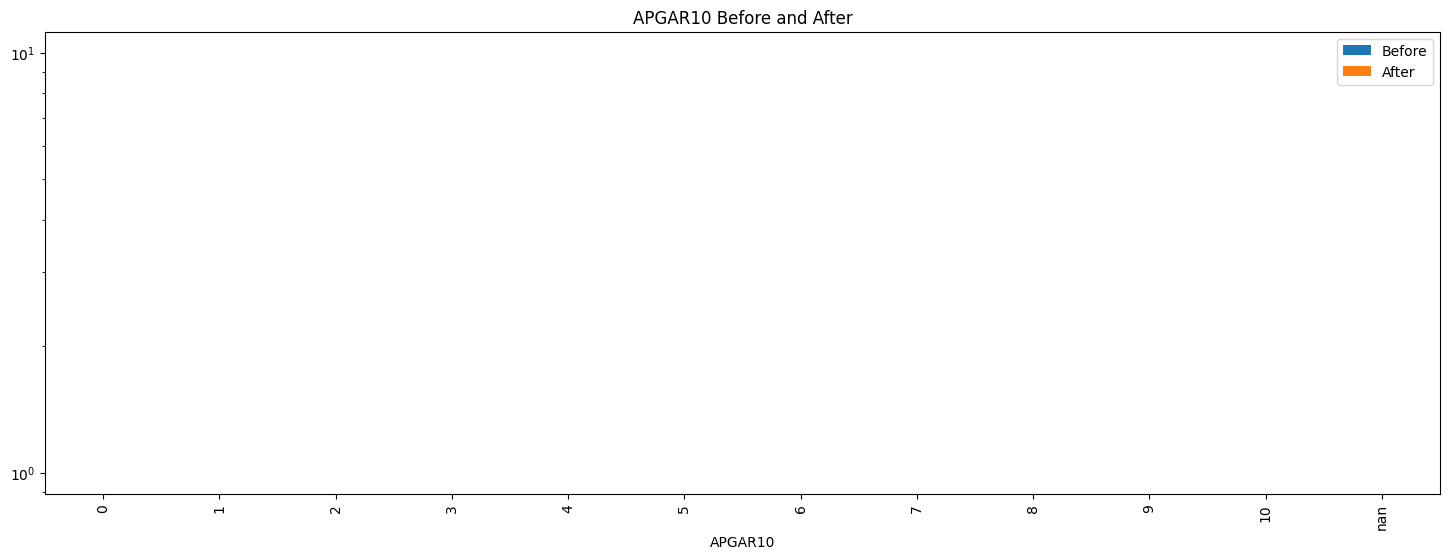

In [20]:
counts_before = manipulation_df_1["APGAR10"].value_counts().sort_index()
counts_after = manipulation_df_1["APGAR10"].value_counts().sort_index()

order = ["0","1","2","3","4","5","6","7","8","9","10","nan"]
apgar_compare = pd.DataFrame({"Before": counts_before, "After": counts_after}).reindex(order)

apgar_compare.plot(kind="bar", figsize=(18,6))
plt.title("APGAR10 Before and After")
plt.yscale("log")
plt.show()

### Fill in the missings in the remaining columns

In [ ]:
categorical = [
    "MAGER14",
    "MRACE31",
    "MEDUC",
    "DMAR",
    "MBSTATE_REC",
    "RESTATUS",
    "WIC",
    "PAY",
    "FAGECOMB",
    "FRACE31",
    "FEDUC",
    "PRECARE",
    "PREVIS",
    "CIG_0_R",
    "CIG_1_R",
    "CIG_2_R",
    "CIG_3_R",
    "BMI_R",
    "PWgt_R",
    "DWgt_R",
    "LBO_REC",
    "TBO_REC",
    "PRIORLIVE",
    "PRIORDEAD",
    "PRIORTERM",
    "ILLB_R11",
    "ILOP_R11",
    "ILP_R11",
    "ME_PRES",
    "ME_ROUT",
    "ME_TRIAL",
    "DMETH_REC",
    "RDMETH_REC",
    "SEX",
    "COMBGEST",
    "GESTREC10",
    "GESTREC3",
    "BWTR14",
    "DPLURAL",
    "APGAR5",
    "APGAR10"
]

medical_binary = ["AB_AVEN1","AB_AVEN6","AB_NICU","AB_SURF","AB_ANTI","AB_SEIZ","CA_ANEN","CA_MNSB","CA_CCHD","CA_CDH",
"CA_OMPH",
"CA_GAST",
"CA_LIMB",
"CA_CLEFT",
"CA_CLPAL",
"CA_DOWN",
"CA_DISOR",
"CA_HYPO",
"MM_MTR",
"MM_PLAC",
"MM_RUPT",
"MM_UHYST",
"MM_AICU",
"IP_GON",
"IP_SYPH",
"IP_CHLAM",
"IP_HEPB",
"IP_HEPC",
"RF_PDIAB",
"RF_GDIAB",
"RF_PHYPE",
"RF_GHYPE",
"RF_EHYPE",
"RF_PPB",
"RF_DRG",
"RF_ART",
"RF_INFT",
"RF_CESAR",
"RF_CESARN",
"LD_INDL",
"LD_AUGM",
"LD_CHOR",
"LD_STER",
"LD_ANTB",
"T"
]

numeric = ["MHTR", "BMI", "WTGAIN"]

In [ ]:
# Filling missing values in medical binary variables with the mode (most frequent value)

for col in medical_binary:
  manipulation_df_1[col] = manipulation_df_1[col].fillna(manipulation_df_2014[col].mode()[0])

In [ ]:
# Filling missing values in other categorical variables based on their distribution

for col in categorical:
  manipulation_df_1[col] = fill_by_prob(manipulation_df_1, col)

In [ ]:
# Filling missing values in numeric variables with the median

for col in numeric:
  manipulation_df_1[col] = pd.to_numeric(manipulation_df_1[col], errors="coerce")
  manipulation_df_1[col] = manipulation_df_1[col].fillna(manipulation_df_1[col].median())

In [ ]:
# Filling summary variables based on their related columns

no_col_to_prefix = {
    "NO_RISKS": "RF_",
    "NO_INFEC": "IP_",
    "NO_ABNORM": "AB_",
    "NO_CONGEN": "CA_",
    "NO_MMORB": "MM_"
}

for no_col, prefix in no_col_to_prefix.items():
  fill_summary_col(manipulation_df_1, prefix, no_col)

In [26]:
manipulation_df_1.isna().sum().tail(50)

IP_HEPC       0
NO_INFEC      0
LD_INDL       0
LD_AUGM       0
LD_CHOR       0
LD_STER       0
LD_ANTB       0
LD_ANES       0
ME_PRES       0
ME_ROUT       0
ME_TRIAL      0
DMETH_REC     0
RDMETH_REC    0
SEX           0
COMBGEST      0
GESTREC10     0
GESTREC3      0
BWTR14        0
APGAR5        0
APGAR10       0
DPLURAL       0
SETORDER_R    0
AB_AVEN1      0
AB_AVEN6      0
AB_NICU       0
AB_SURF       0
AB_ANTI       0
AB_SEIZ       0
NO_ABNORM     0
CA_ANEN       0
CA_MNSB       0
CA_CCHD       0
CA_CDH        0
CA_OMPH       0
CA_GAST       0
CA_LIMB       0
CA_CLEFT      0
CA_CLPAL      0
CA_DOWN       0
CA_DISOR      0
CA_HYPO       0
NO_CONGEN     0
MM_MTR        0
MM_PLAC       0
MM_RUPT       0
MM_UHYST      0
MM_AICU       0
NO_MMORB      0
T             0
Y             0
dtype: int64

## Grouping columns

In [ ]:
system_groups = {
    "Cardio_Blood": ["RF_PHYPE", "RF_GHYPE", "RF_EHYPE", "RF_PPB", "CA_CCHD", "CA_DOWN", "CA_DISOR"],
    "Metabolic_Endocrine": ["RF_PDIAB", "RF_GDIAB"],
    "Reproductive": ["RF_INFT", "CA_HYPO", "CA_DOWN", "CA_DISOR"],
    "Digestive": ["CA_GAST", "CA_OMPH", "CA_CDH", "CA_DOWN", "CA_DISOR"],
    "Nervous": ["CA_ANEN", "CA_MNSB", "AB_SEIZ", "CA_DOWN", "CA_DISOR"],
    "Respiratory": ["AB_SURF"],
    "Pregnancy_Complications": ["RF_DRG", "RF_ART", "RF_CESAR"],
    "Infections": ["IP_GON", "IP_SYPH", "IP_CHLAM", "IP_HEPB", "IP_HEPC"],
    "Labor_Delivery_Interventions": ["LD_INDL", "LD_AUGM", "LD_CHOR", "LD_STER", "LD_ANTB", "ME_TRIAL"],
    "Neonatal_Care": ["AB_AVEN1", "AB_AVEN6", "AB_NICU", "AB_ANTI"],
    "Congenital_Anomalies": ["CA_LIMB", "CA_CLEFT", "CA_CLPAL", "MM_MTR", "MM_PLAC", "MM_RUPT", "MM_UHYST", "MM_AICU"]
}

# We can create new features based on the system groups by taking the maximum value across the related columns for each row.
# This will indicate whether any of the conditions in that system group are present for each record.

In [28]:
for system, cols in system_groups.items():
  manipulation_df_1[system] = 0
  total_weight = 0
  for col in cols:
    weight = 0.5 if col in ["CA_DOWN", "CA_DISOR"] else 1
    total_weight += weight
    manipulation_df_1[system] += ((manipulation_df_1[col] == "Y").astype(int) * weight)
  manipulation_df_1[system] /= total_weight

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\8187077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  manipulation_df_1[system] = 0
C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\8187077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  manipulation_df_1[system] = 0
C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\8187077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

In [29]:
system_columns = list(system_groups.keys())

summary_table = pd.DataFrame({
    "System": system_columns,
    "Columns Included": [", ".join(system_groups[s]) for s in system_columns],
    "Description": [
        "Cardio & Blood – heart and circulatory conditions",
        "Metabolic & Endocrine – diabetes and hormonal conditions",
        "Reproductive – infertility and reproductive health issues",
        "Digestive – stomach and gut conditions",
        "Nervous – neurological and brain conditions",
        "Respiratory – breathing and lung-related conditions",
        "Pregnancy Complications – interventions, cesarean, complications during labor",
        "Infections – maternal infections during pregnancy",
        "Labor & Delivery Interventions – labor procedures and medications",
        "Neonatal Care – newborn care and complications",
        "Congenital Anomalies – birth defects and structural anomalies"
    ]
})

summary_table

,System,Columns Included,Description
0,Cardio_Blood,"RF_PHYPE, RF_GHYPE, RF_EHYPE, RF_PPB, CA_CCHD,...",Cardio & Blood – heart and circulatory conditions
1,Metabolic_Endocrine,"RF_PDIAB, RF_GDIAB",Metabolic & Endocrine – diabetes and hormonal ...
2,Reproductive,"RF_INFT, CA_HYPO, CA_DOWN, CA_DISOR",Reproductive – infertility and reproductive he...
3,Digestive,"CA_GAST, CA_OMPH, CA_CDH, CA_DOWN, CA_DISOR",Digestive – stomach and gut conditions
4,Nervous,"CA_ANEN, CA_MNSB, AB_SEIZ, CA_DOWN, CA_DISOR",Nervous – neurological and brain conditions
5,Respiratory,AB_SURF,Respiratory – breathing and lung-related condi...
6,Pregnancy_Complications,"RF_DRG, RF_ART, RF_CESAR","Pregnancy Complications – interventions, cesar..."
7,Infections,"IP_GON, IP_SYPH, IP_CHLAM, IP_HEPB, IP_HEPC",Infections – maternal infections during pregnancy
8,Labor_Delivery_Interventions,"LD_INDL, LD_AUGM, LD_CHOR, LD_STER, LD_ANTB, M...",Labor & Delivery Interventions – labor procedu...
9,Neonatal_Care,"AB_AVEN1, AB_AVEN6, AB_NICU, AB_ANTI",Neonatal Care – newborn care and complications


## Outliers

In [30]:
numeric_cols = ['BMI', 'WTGAIN', 'FAGECOMB', 'PREVIS']

---------------------------------------------------BMI---------------------------------------------------


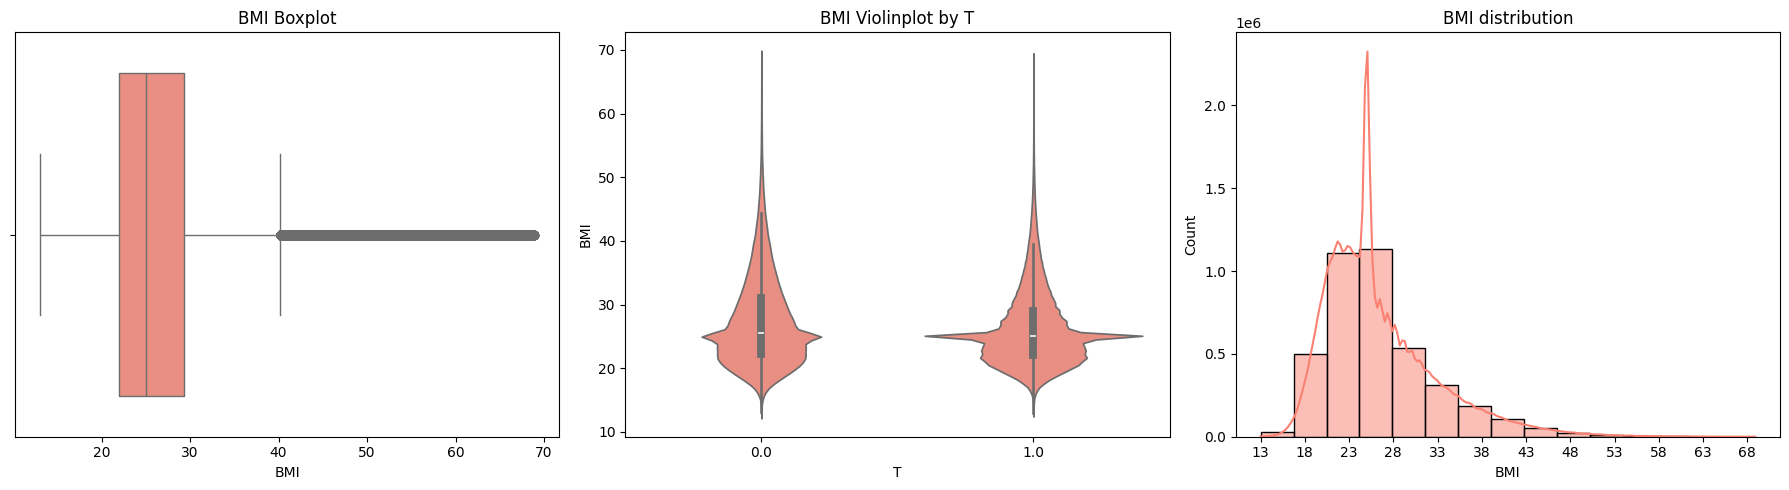

---------------------------------------------------WTGAIN---------------------------------------------------


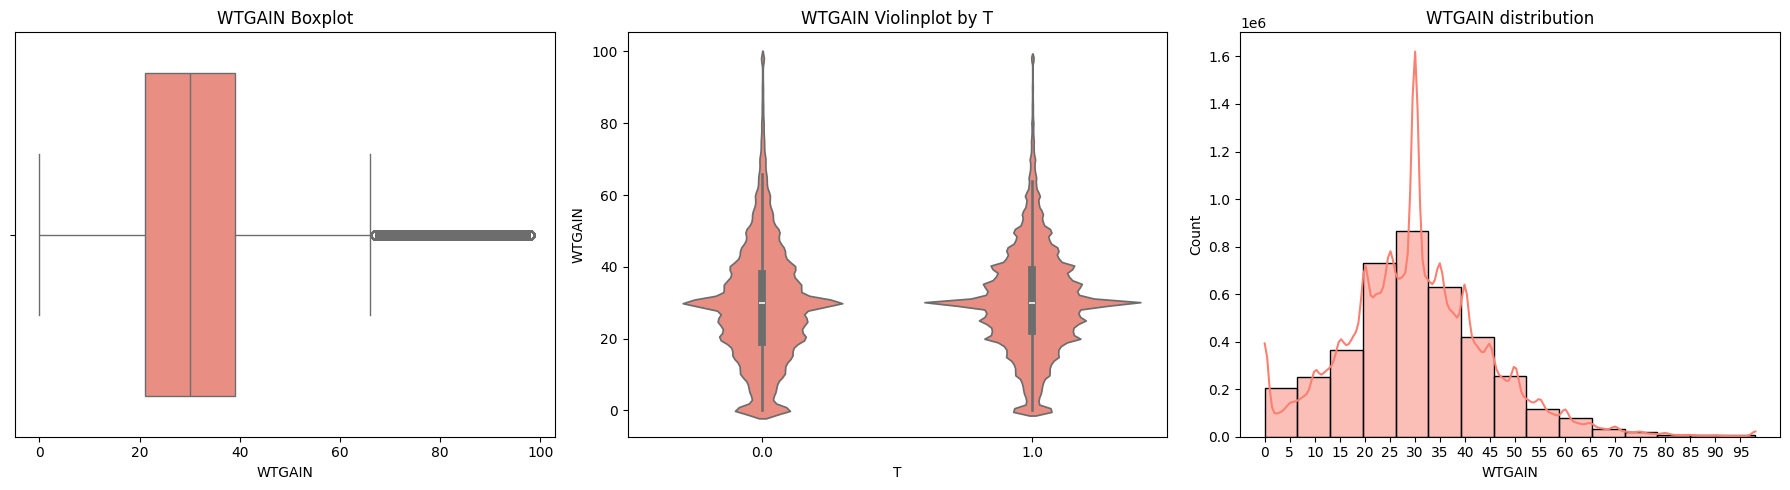

---------------------------------------------------FAGECOMB---------------------------------------------------


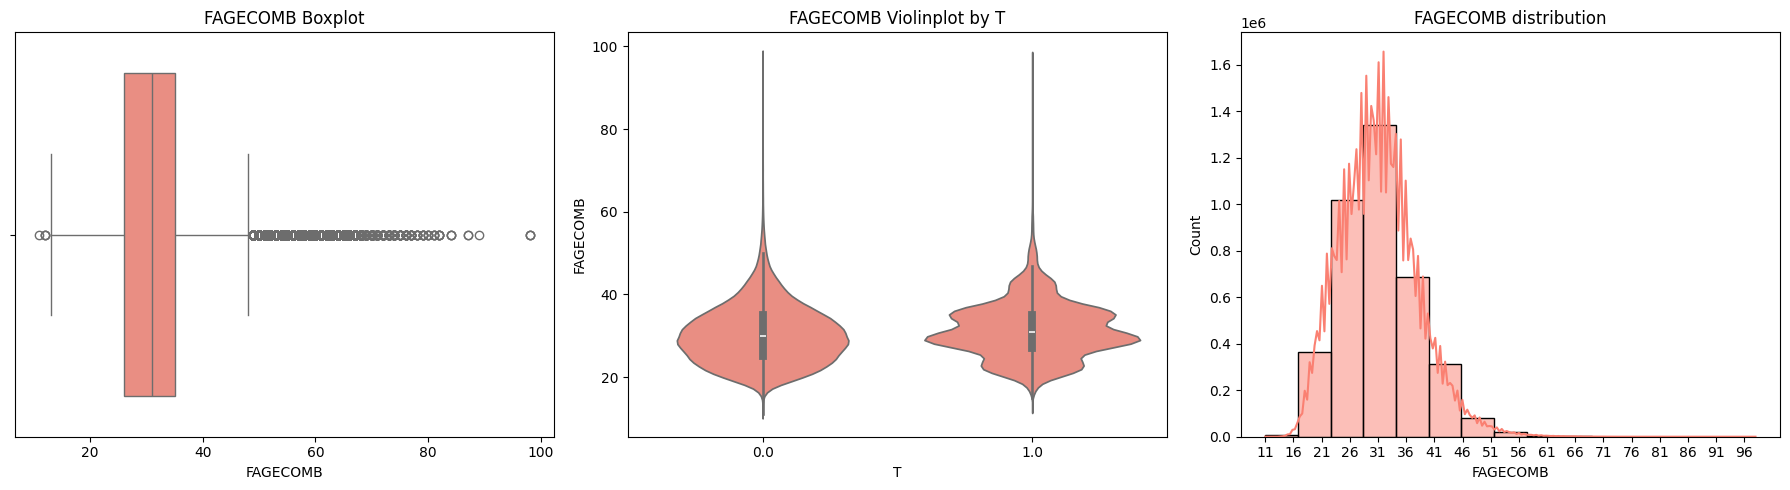

---------------------------------------------------PREVIS---------------------------------------------------


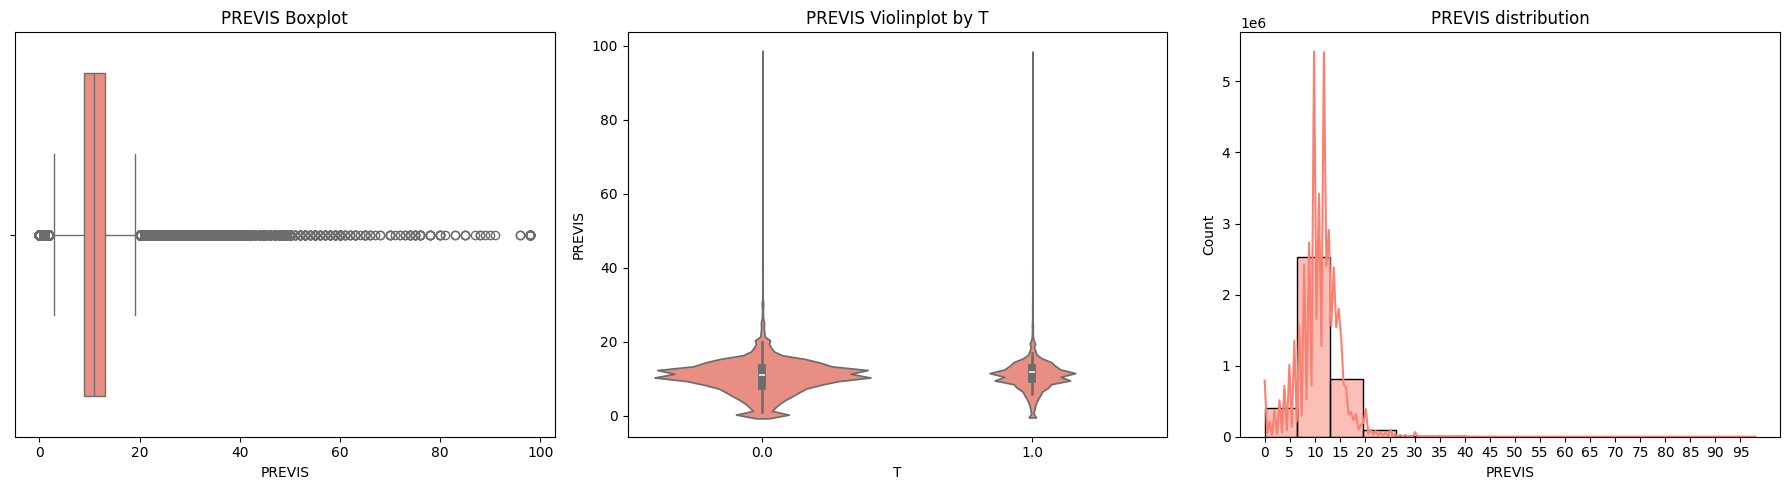

In [31]:
df_plot = convert_missing_to_nan(manipulation_df_1, nchs_missing_per_var)

for col in numeric_cols:
  print(f"---------------------------------------------------{col}---------------------------------------------------")
  plot_continuous(col, df_plot)

---------------------------------------------------BMI---------------------------------------------------


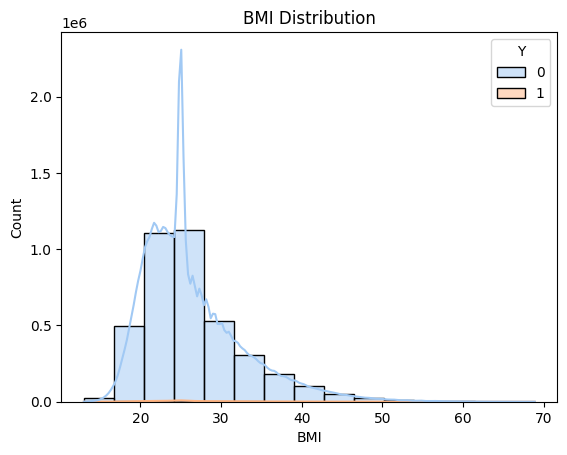

---------------------------------------------------WTGAIN---------------------------------------------------


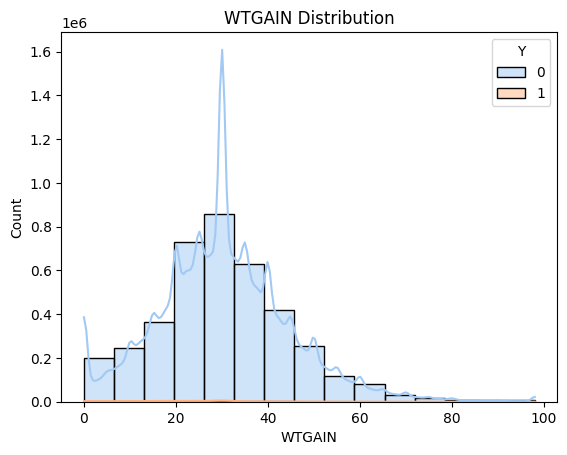

---------------------------------------------------FAGECOMB---------------------------------------------------


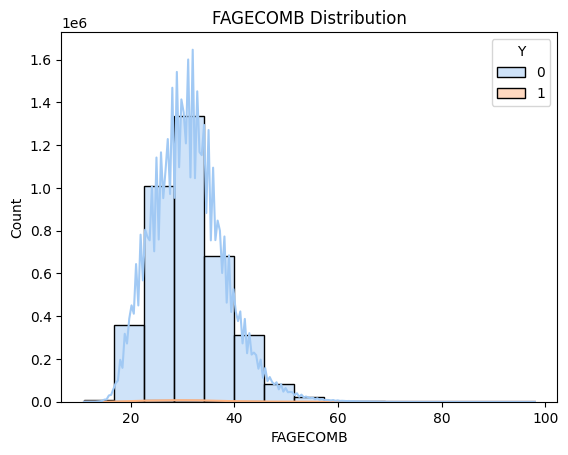

---------------------------------------------------PREVIS---------------------------------------------------


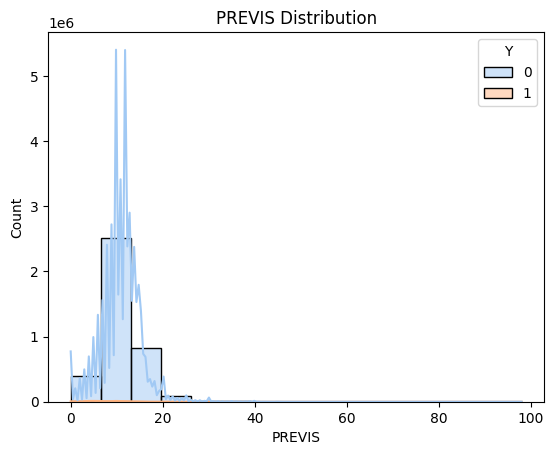

In [32]:
for col in numeric_cols:
  print(f"---------------------------------------------------{col}---------------------------------------------------")
  sns.histplot(df_plot, x = col, palette = "pastel", hue = "Y", bins = 15, kde = True)
  plt.title(col + " Distribution")
  plt.show()

In [33]:
df_plot[numeric_cols].describe()

,BMI,WTGAIN,FAGECOMB,PREVIS
count,3.998175e+06,3.998175e+06,3.835635e+06,3.851311e+06
mean,2.643088e+01,3.036298e+01,3.119768e+01,1.123730e+01
std,6.320462e+00,1.471047e+01,6.849159e+00,4.116604e+00
min,1.300000e+01,0.000000e+00,1.100000e+01,0.000000e+00
25%,2.200000e+01,2.100000e+01,2.600000e+01,9.000000e+00
50%,2.500000e+01,3.000000e+01,3.100000e+01,1.100000e+01
75%,2.930000e+01,3.900000e+01,3.500000e+01,1.300000e+01
max,6.890000e+01,9.800000e+01,9.800000e+01,9.800000e+01


## Keeping the updated data - 2015

In [ ]:
#manipulation_df_1.to_csv('df_export.csv', index=False)
#files.download('df_export.csv')

#manipulation_df_1.to_csv(r'E:\manipulation_df_21_03_2026.csv', index=False)

#Not needed to run again, just for export

In [35]:
#manipulation_df_1.shape

#Not needed to run again, just for export

(3998175, 108)

In [38]:
#manipulation_2014_sample = manipulation_df_1.sample(n=10000, random_state=42)

#Not needed to run again, just for export

In [39]:
#print(manipulation_2014_sample.shape)

#Not needed to run again, just for export

(10000, 108)


In [ ]:
#manipulation_2015_sample.to_csv(r'E:\manipulation_2015_sample_22_03_2026.csv', index=False)

#Not needed to run again, just for export

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\811281468.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=manipulation_2014_sample, x="Y", palette="pastel")


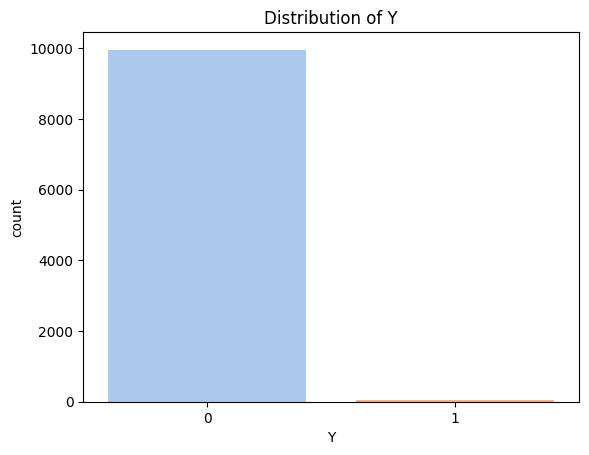

In [ ]:
manipulation_2015_sample = manipulation_df_1.sample(n=10000, random_state=42)
sns.countplot(data=manipulation_2015_sample, x="Y", palette="pastel")
plt.title("Distribution of Y")
plt.show()

# 2014 Data

## Data importing - 2014

In [ ]:
#file_id = "1JMrg1OpkWK4RxuRwJaEKKtnr2kNam9vg"
#output = "df_small.csv"

#!gdown --id {file_id} -O {output}

#df = pd.read_csv(output)
#df.head()

df_2014 = pd.read_csv('data/final_data_df_2014.csv')
df_2014.head()

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\2694374653.py:9: DtypeWarning: Columns (1,2,7,8,9,10,21,22,23,24,25,26,27,28,29,30,31,32,33,40,41,42,48,55,56,58,66,68,75,88,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'E:\final_data_df_2014.csv')


,MAGER14,MRACE31,MEDUC,DMAR,MBSTATE_REC,RESTATUS,WIC,PAY,FAGECOMB,FRACE31,...,CA_HYPO,NO_CONGEN,MM_MTR,MM_PLAC,MM_RUPT,MM_UHYST,MM_AICU,NO_MMORB,T,Y
0,9,1,7,1,1,1,N,5,35,1,...,N,1,N,N,N,N,N,1,1.0,0
1,9,3,3,2,1,1,N,1,99,99,...,N,1,N,N,N,N,N,1,0.0,0
2,8,1,4,1,1,2,Y,5,22,1,...,N,1,N,N,N,N,N,1,1.0,0
3,8,2,5,2,1,1,Y,5,99,99,...,N,1,N,N,N,N,N,1,1.0,0
4,9,1,5,1,1,1,Y,5,25,1,...,N,1,N,N,N,N,N,1,1.0,0


## Y - 2014

In [ ]:
analyze_variable(df_2014, 'Y')

{'variable_name': 'Y',
 'position': 97,
 'type': 'int64',
 'values': [np.int64(0), np.int64(1)],
 'missing_values': np.int64(0),
 'dominant_value': np.int64(0)}

## manipulation - 2014

In [ ]:
manipulation_df_2014 = df_2014.copy()
del df_2014
gc.collect()

0

In [ ]:
manipulation_df_2014 = convert_missing_to_nan(manipulation_df_2014, nchs_missing_per_var)
manipulation_df_2014 = manipulation_df_2014[manipulation_df_2014["Y"].notna()]

### Filling in missing values ​​in Apgar 10 and in Apgar 5

In [ ]:
for col in ["APGAR10", "APGAR5"]:
    manipulation_df_2014[col] = (
        manipulation_df_2014[col]
        .astype(str)
        .str.strip()
        .replace("", np.nan)
    )
    manipulation_df_2014[col] = pd.to_numeric(manipulation_df_2014[col], errors="coerce")

manipulation_df_2014["APGAR10"] = manipulation_df_2014["APGAR10"].replace(88, np.nan)
manipulation_df_2014["APGAR10"] = manipulation_df_2014["APGAR10"].fillna(manipulation_df_2014["APGAR5"])

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\2886521953.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


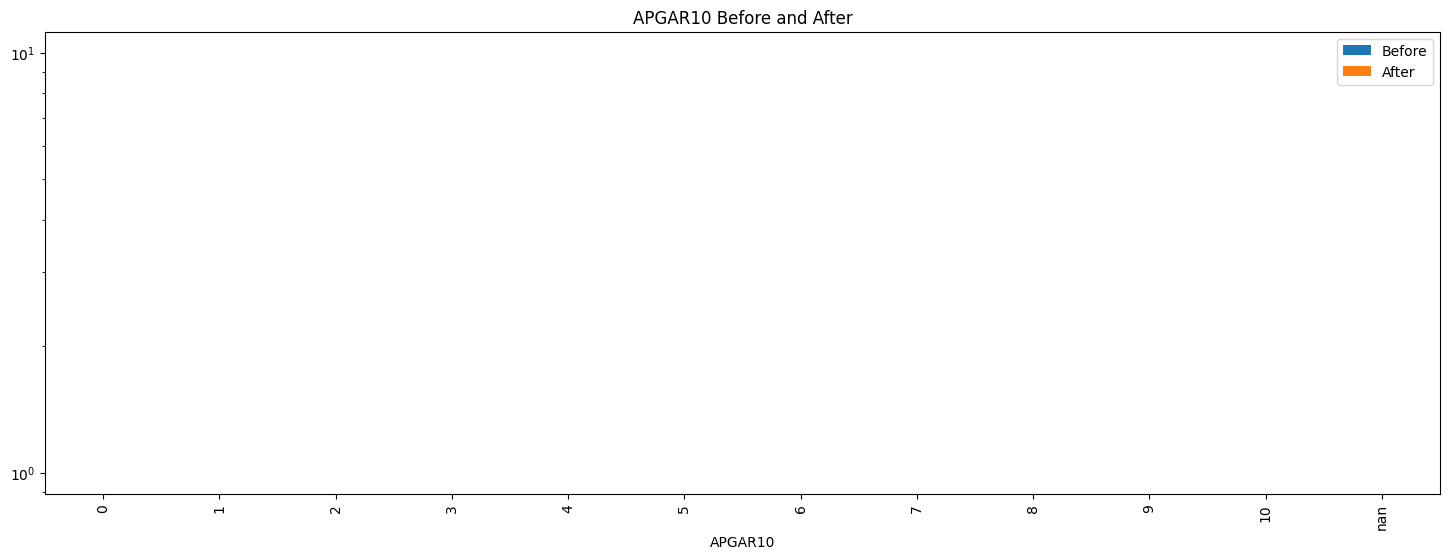

In [ ]:
counts_before = manipulation_df_2014["APGAR10"].value_counts().sort_index()
counts_after = manipulation_df_2014["APGAR10"].value_counts().sort_index()

order = ["0","1","2","3","4","5","6","7","8","9","10","nan"]
apgar_compare = pd.DataFrame({"Before": counts_before, "After": counts_after}).reindex(order)

apgar_compare.plot(kind="bar", figsize=(18,6))
plt.title("APGAR10 Before and After")
plt.yscale("log")
plt.show()

### Fill in the missings in the remaining columns

In [ ]:
categorical = [
    "MAGER14",
    "MRACE31",
    "MEDUC",
    "DMAR",
    "MBSTATE_REC",
    "RESTATUS",
    "WIC",
    "PAY",
    "FAGECOMB",
    "FRACE31",
    "FEDUC",
    "PRECARE",
    "PREVIS",
    "CIG_0_R",
    "CIG_1_R",
    "CIG_2_R",
    "CIG_3_R",
    "BMI_R",
    "PWgt_R",
    "DWgt_R",
    "LBO_REC",
    "TBO_REC",
    "PRIORLIVE",
    "PRIORDEAD",
    "PRIORTERM",
    "ILLB_R11",
    "ILOP_R11",
    "ILP_R11",
    "ME_PRES",
    "ME_ROUT",
    "ME_TRIAL",
    "DMETH_REC",
    "RDMETH_REC",
    "SEX",
    "COMBGEST",
    "GESTREC10",
    "GESTREC3",
    "BWTR14",
    "DPLURAL",
    "APGAR5",
    "APGAR10"
]

medical_binary = ["AB_AVEN1","AB_AVEN6","AB_NICU","AB_SURF","AB_ANTI","AB_SEIZ","CA_ANEN","CA_MNSB","CA_CCHD","CA_CDH",
"CA_OMPH",
"CA_GAST",
"CA_LIMB",
"CA_CLEFT",
"CA_CLPAL",
"CA_DOWN",
"CA_DISOR",
"CA_HYPO",
"MM_MTR",
"MM_PLAC",
"MM_RUPT",
"MM_UHYST",
"MM_AICU",
"IP_GON",
"IP_SYPH",
"IP_CHLAM",
"IP_HEPB",
"IP_HEPC",
"RF_PDIAB",
"RF_GDIAB",
"RF_PHYPE",
"RF_GHYPE",
"RF_EHYPE",
"RF_PPB",
"RF_DRG",
"RF_ART",
"RF_INFT",
"RF_CESAR",
"RF_CESARN",
"LD_INDL",
"LD_AUGM",
"LD_CHOR",
"LD_STER",
"LD_ANTB",
"T"
]

numeric = ["MHTR", "BMI", "WTGAIN"]

In [ ]:
# Filling missing values in medical binary variables with the mode (most frequent value)

for col in medical_binary:
  manipulation_df_2014[col] = manipulation_df_2014[col].fillna(manipulation_df_2014[col].mode()[0])

In [ ]:
# Filling missing values in other categorical variables based on their distribution

for col in categorical:
  manipulation_df_2014[col] = fill_by_prob(manipulation_df_2014, col)

In [ ]:
# Filling missing values in numeric variables with the median

for col in numeric:
  manipulation_df_2014[col] = pd.to_numeric(manipulation_df_2014[col], errors="coerce")
  manipulation_df_2014[col] = manipulation_df_2014[col].fillna(manipulation_df_2014[col].median())

In [ ]:
# Filling summary variables based on their related columns

no_col_to_prefix = {
    "NO_RISKS": "RF_",
    "NO_INFEC": "IP_",
    "NO_ABNORM": "AB_",
    "NO_CONGEN": "CA_",
    "NO_MMORB": "MM_"
}

for no_col, prefix in no_col_to_prefix.items():
  fill_summary_col(manipulation_df_2014, prefix, no_col)

In [ ]:
manipulation_df_2014.isna().sum().tail(50)

IP_HEPC       0
NO_INFEC      0
LD_INDL       0
LD_AUGM       0
LD_CHOR       0
LD_STER       0
LD_ANTB       0
LD_ANES       0
ME_PRES       0
ME_ROUT       0
ME_TRIAL      0
DMETH_REC     0
RDMETH_REC    0
SEX           0
COMBGEST      0
GESTREC10     0
GESTREC3      0
BWTR14        0
APGAR5        0
APGAR10       0
DPLURAL       0
SETORDER_R    0
AB_AVEN1      0
AB_AVEN6      0
AB_NICU       0
AB_SURF       0
AB_ANTI       0
AB_SEIZ       0
NO_ABNORM     0
CA_ANEN       0
CA_MNSB       0
CA_CCHD       0
CA_CDH        0
CA_OMPH       0
CA_GAST       0
CA_LIMB       0
CA_CLEFT      0
CA_CLPAL      0
CA_DOWN       0
CA_DISOR      0
CA_HYPO       0
NO_CONGEN     0
MM_MTR        0
MM_PLAC       0
MM_RUPT       0
MM_UHYST      0
MM_AICU       0
NO_MMORB      0
T             0
Y             0
dtype: int64

## Grouping columns

In [ ]:
system_groups = {
    "Cardio_Blood": ["RF_PHYPE", "RF_GHYPE", "RF_EHYPE", "RF_PPB", "CA_CCHD", "CA_DOWN", "CA_DISOR"],
    "Metabolic_Endocrine": ["RF_PDIAB", "RF_GDIAB"],
    "Reproductive": ["RF_INFT", "CA_HYPO", "CA_DOWN", "CA_DISOR"],
    "Digestive": ["CA_GAST", "CA_OMPH", "CA_CDH", "CA_DOWN", "CA_DISOR"],
    "Nervous": ["CA_ANEN", "CA_MNSB", "AB_SEIZ", "CA_DOWN", "CA_DISOR"],
    "Respiratory": ["AB_SURF"],
    "Pregnancy_Complications": ["RF_DRG", "RF_ART", "RF_CESAR"],
    "Infections": ["IP_GON", "IP_SYPH", "IP_CHLAM", "IP_HEPB", "IP_HEPC"],
    "Labor_Delivery_Interventions": ["LD_INDL", "LD_AUGM", "LD_CHOR", "LD_STER", "LD_ANTB", "ME_TRIAL"],
    "Neonatal_Care": ["AB_AVEN1", "AB_AVEN6", "AB_NICU", "AB_ANTI"],
    "Congenital_Anomalies": ["CA_LIMB", "CA_CLEFT", "CA_CLPAL", "MM_MTR", "MM_PLAC", "MM_RUPT", "MM_UHYST", "MM_AICU"]
}

# We can create new features based on the system groups by taking the maximum value across the related columns for each row.
# This will indicate whether any of the conditions in that system group are present for each record.

In [ ]:
for system, cols in system_groups.items():
  manipulation_df_2014[system] = 0
  total_weight = 0
  for col in cols:
    weight = 0.5 if col in ["CA_DOWN", "CA_DISOR"] else 1
    total_weight += weight
    manipulation_df_2014[system] += ((manipulation_df_2014[col] == "Y").astype(int) * weight)
  manipulation_df_2014[system] /= total_weight

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\8187077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  manipulation_df_1[system] = 0
C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\8187077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  manipulation_df_1[system] = 0
C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\8187077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

In [ ]:
system_columns = list(system_groups.keys())

summary_table = pd.DataFrame({
    "System": system_columns,
    "Columns Included": [", ".join(system_groups[s]) for s in system_columns],
    "Description": [
        "Cardio & Blood – heart and circulatory conditions",
        "Metabolic & Endocrine – diabetes and hormonal conditions",
        "Reproductive – infertility and reproductive health issues",
        "Digestive – stomach and gut conditions",
        "Nervous – neurological and brain conditions",
        "Respiratory – breathing and lung-related conditions",
        "Pregnancy Complications – interventions, cesarean, complications during labor",
        "Infections – maternal infections during pregnancy",
        "Labor & Delivery Interventions – labor procedures and medications",
        "Neonatal Care – newborn care and complications",
        "Congenital Anomalies – birth defects and structural anomalies"
    ]
})

summary_table

,System,Columns Included,Description
0,Cardio_Blood,"RF_PHYPE, RF_GHYPE, RF_EHYPE, RF_PPB, CA_CCHD,...",Cardio & Blood – heart and circulatory conditions
1,Metabolic_Endocrine,"RF_PDIAB, RF_GDIAB",Metabolic & Endocrine – diabetes and hormonal ...
2,Reproductive,"RF_INFT, CA_HYPO, CA_DOWN, CA_DISOR",Reproductive – infertility and reproductive he...
3,Digestive,"CA_GAST, CA_OMPH, CA_CDH, CA_DOWN, CA_DISOR",Digestive – stomach and gut conditions
4,Nervous,"CA_ANEN, CA_MNSB, AB_SEIZ, CA_DOWN, CA_DISOR",Nervous – neurological and brain conditions
5,Respiratory,AB_SURF,Respiratory – breathing and lung-related condi...
6,Pregnancy_Complications,"RF_DRG, RF_ART, RF_CESAR","Pregnancy Complications – interventions, cesar..."
7,Infections,"IP_GON, IP_SYPH, IP_CHLAM, IP_HEPB, IP_HEPC",Infections – maternal infections during pregnancy
8,Labor_Delivery_Interventions,"LD_INDL, LD_AUGM, LD_CHOR, LD_STER, LD_ANTB, M...",Labor & Delivery Interventions – labor procedu...
9,Neonatal_Care,"AB_AVEN1, AB_AVEN6, AB_NICU, AB_ANTI",Neonatal Care – newborn care and complications


## Outliers

In [ ]:
numeric_cols = ['BMI', 'WTGAIN', 'FAGECOMB', 'PREVIS']

---------------------------------------------------BMI---------------------------------------------------


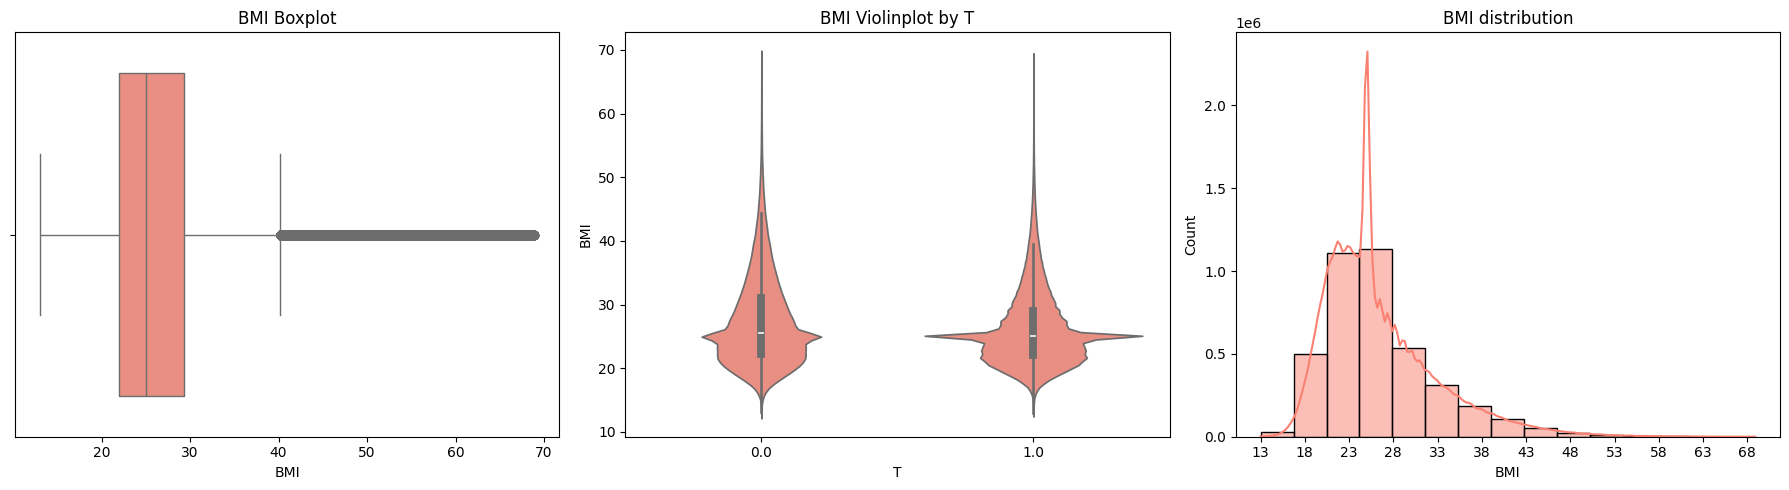

---------------------------------------------------WTGAIN---------------------------------------------------


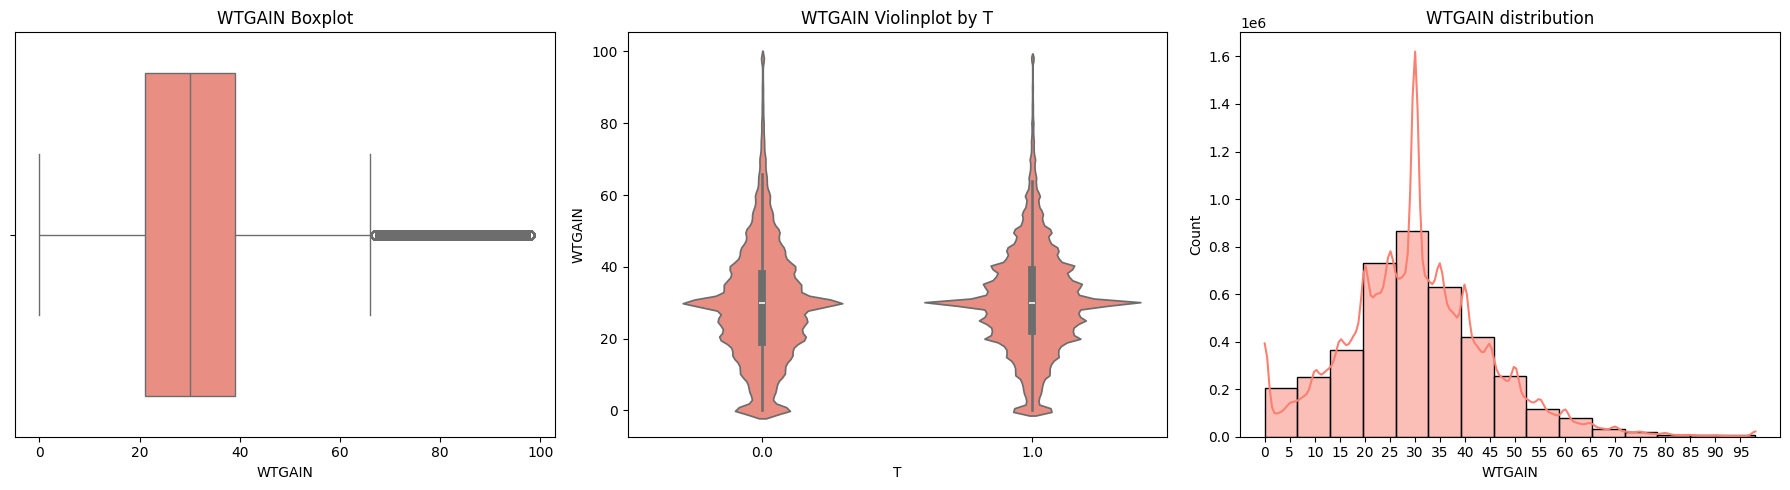

---------------------------------------------------FAGECOMB---------------------------------------------------


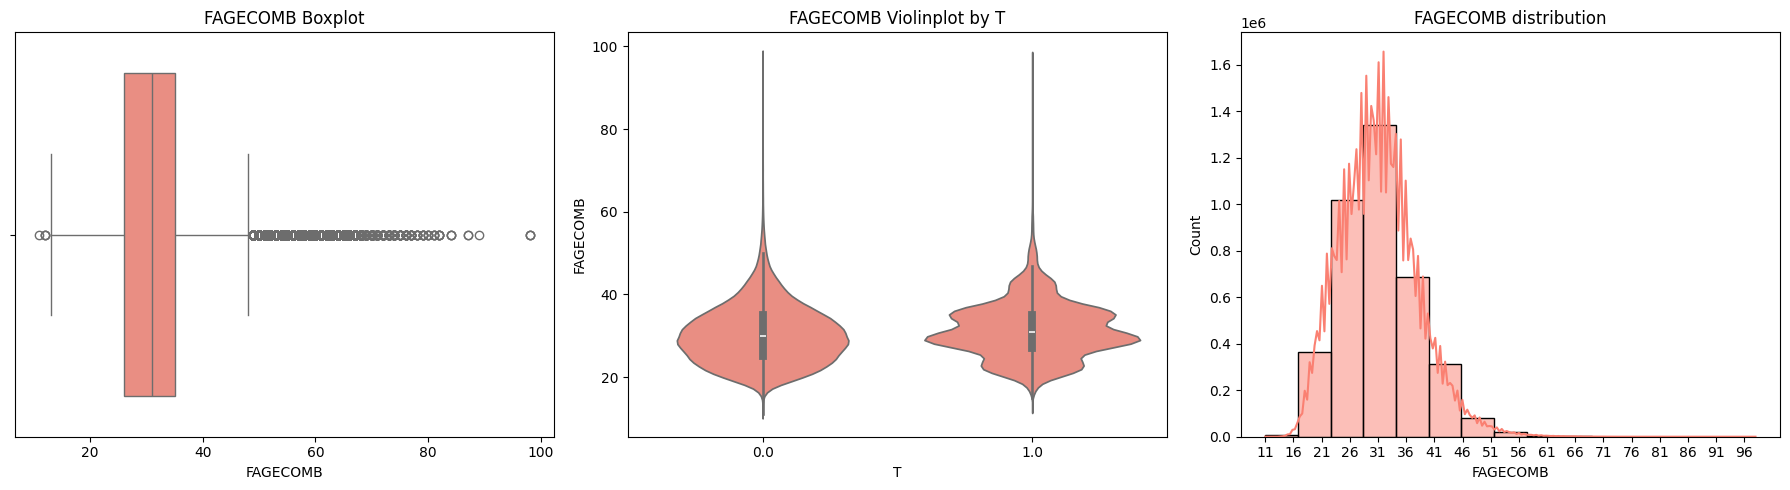

---------------------------------------------------PREVIS---------------------------------------------------


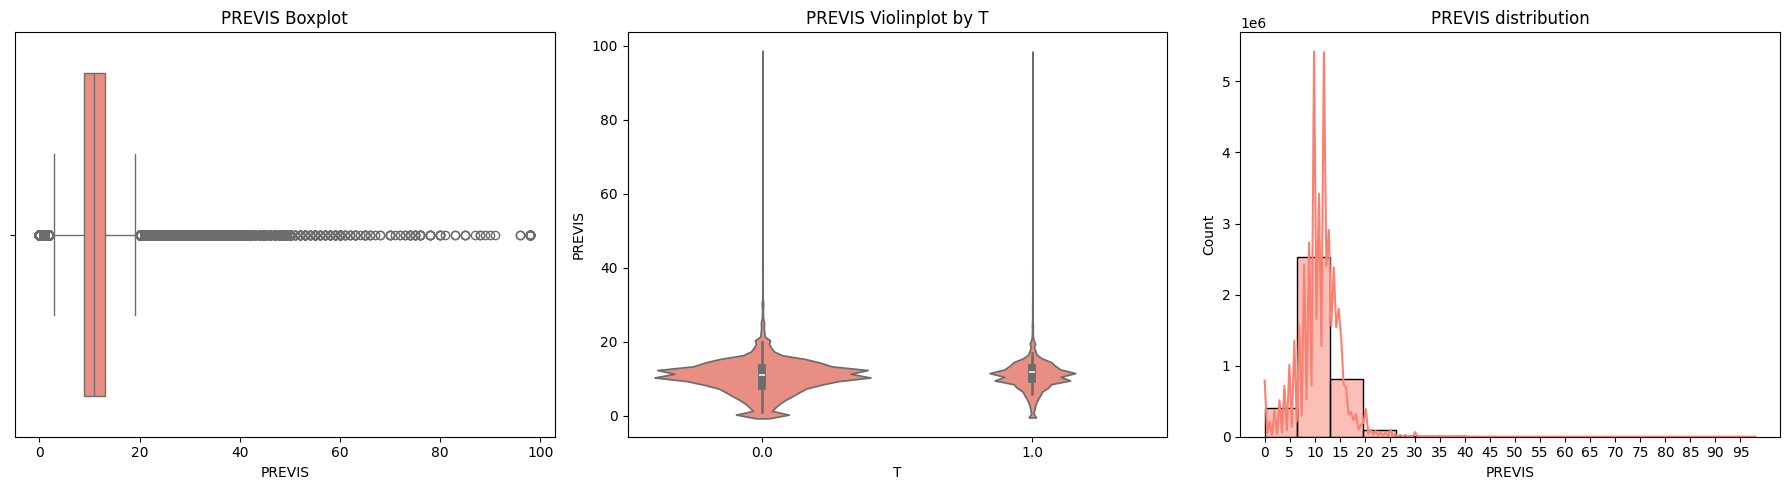

In [ ]:
df_plot = convert_missing_to_nan(manipulation_df_2014, nchs_missing_per_var)

for col in numeric_cols:
  print(f"---------------------------------------------------{col}---------------------------------------------------")
  plot_continuous(col, df_plot)

---------------------------------------------------BMI---------------------------------------------------


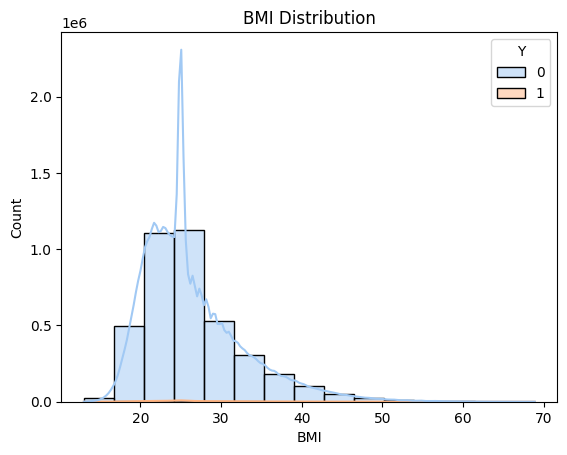

---------------------------------------------------WTGAIN---------------------------------------------------


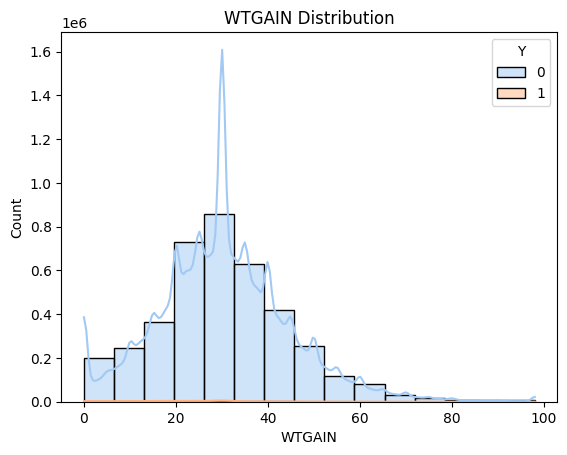

---------------------------------------------------FAGECOMB---------------------------------------------------


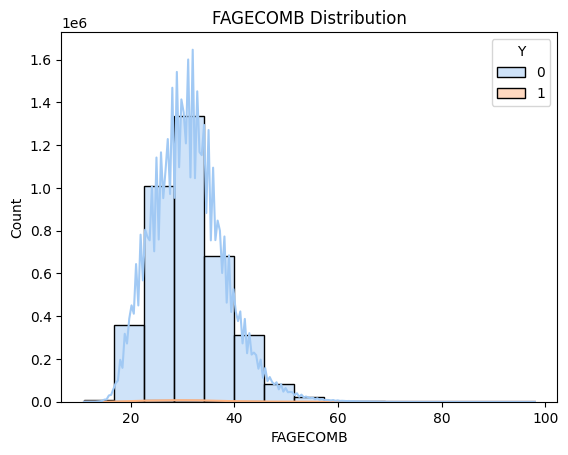

---------------------------------------------------PREVIS---------------------------------------------------


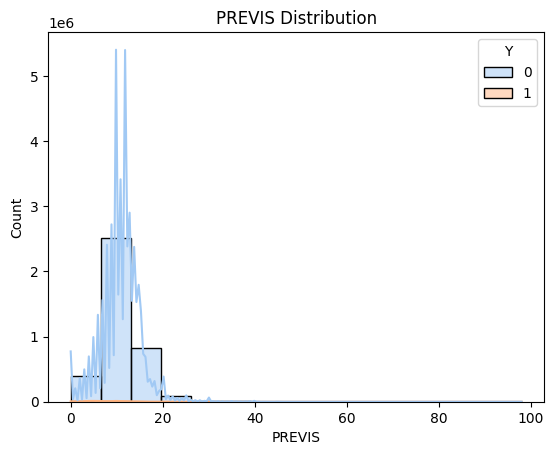

In [ ]:
for col in numeric_cols:
  print(f"---------------------------------------------------{col}---------------------------------------------------")
  sns.histplot(df_plot, x = col, palette = "pastel", hue = "Y", bins = 15, kde = True)
  plt.title(col + " Distribution")
  plt.show()

In [ ]:
df_plot[numeric_cols].describe()

,BMI,WTGAIN,FAGECOMB,PREVIS
count,3.998175e+06,3.998175e+06,3.835635e+06,3.851311e+06
mean,2.643088e+01,3.036298e+01,3.119768e+01,1.123730e+01
std,6.320462e+00,1.471047e+01,6.849159e+00,4.116604e+00
min,1.300000e+01,0.000000e+00,1.100000e+01,0.000000e+00
25%,2.200000e+01,2.100000e+01,2.600000e+01,9.000000e+00
50%,2.500000e+01,3.000000e+01,3.100000e+01,1.100000e+01
75%,2.930000e+01,3.900000e+01,3.500000e+01,1.300000e+01
max,6.890000e+01,9.800000e+01,9.800000e+01,9.800000e+01


## Keeping the updated data - 2014

In [ ]:
#manipulation_df_1.to_csv('df_export.csv', index=False)
#files.download('df_export.csv')

#manipulation_df_1.to_csv(r'E:\manipulation_df2014_22_03_2026.csv', index=False)

#Not needed to run again, just for export

In [ ]:
#manipulation_df_1.shape

#Not needed to run again, just for export

(3998175, 108)

In [ ]:
#manipulation_2014_sample = manipulation_df_1.sample(n=10000, random_state=42)

#Not needed to run again, just for export

In [ ]:
#print(manipulation_2014_sample.shape)

#Not needed to run again, just for export

(10000, 108)


In [ ]:
#manipulation_2014_sample.to_csv(r'E:\manipulation_2014_sample_22_03_2026.csv', index=False)

#Not needed to run again, just for export

C:\Users\Almog\AppData\Local\Temp\ipykernel_7768\811281468.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=manipulation_2014_sample, x="Y", palette="pastel")


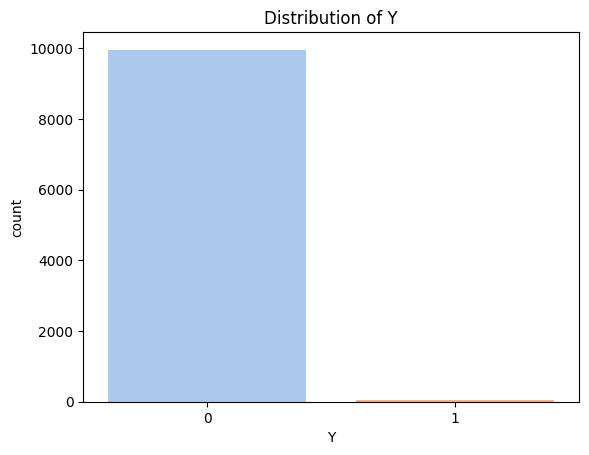

In [ ]:
manipulation_2014_sample = manipulation_df_2014.sample(n=10000, random_state=42)
sns.countplot(data=manipulation_2014_sample, x="Y", palette="pastel")
plt.title("Distribution of Y")
plt.show()